# 📊 Projeto 1: Análise Exploratória e Decomposição de Séries Temporais

Neste notebook, realizamos a primeira etapa do projeto de previsão de consumo de energia elétrica:
1. **Geração e Simulação de Dados**: Criação de uma série temporal contendo tendência determinística, sazonalidades (anual e semanal) e ruído estocástico gaussiano.
2. **Teste de Estacionariedade (ADF Test)**: Aplicação do teste de Dickey-Fuller Aumentado para validar a necessidade de diferenciação da série.
3. **Decomposição Temporal Clássica**: Isolamento dos componentes de tendência, sazonalidade e resíduos.

---

## 1. Importação das Bibliotecas Necessárias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Configuração estática do estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Simulação da Série Temporal de Consumo de Energia

A série temporal $y_t$ é modelada aditivamente segundo a equação:

$$y_t = T_t + S^{\text{anual}}_t + S^{\text{semanal}}_t + \epsilon_t$$

Onde:
* $T_t$: Tendência linear de crescimento.
* $S^{\text{anual}}_t = 30 \cdot \sin\left(\frac{2\pi \cdot \text{dia}}{365}\right)$: Componente sazonal anual.
* $S^{\text{semanal}}_t = 15 \cdot \sin\left(\frac{2\pi \cdot \text{dia}}{7}\right)$: Componente sazonal semanal.
* $\epsilon_t \sim \mathcal{N}(0, 8^2)$: Ruído estocástico gaussiano.

In [2]:
def carregar_dados():
    """Gera uma série temporal simulada de consumo diário de energia elétrica (MWh)."""
    np.random.seed(42)
    datas = pd.date_range(start="2023-01-01", end="2025-12-31", freq="D")
    n = len(datas)

    # Componentes da série temporal
    tendencia = np.linspace(100, 250, n)  # Crescimento ao longo do tempo
    sazonalidade_anual = 30 * np.sin(
        2 * np.pi * datas.dayofyear / 365
    )  # Ciclo anual
    sazonalidade_semanal = 15 * np.sin(
        2 * np.pi * datas.dayofweek / 7
    )  # Ciclo semanal
    ruido = np.random.normal(0, 8, n)  # Flutuação estocástica

    consumo = tendencia + sazonalidade_anual + sazonalidade_semanal + ruido

    df = pd.DataFrame({"data": datas, "consumo_mwh": consumo})
    df.set_index("data", inplace=True)
    return df


# Execução e exibição das primeiras linhas
df = carregar_dados()
df.head()

,consumo_mwh
data,
2023-01-01,92.762642
2023-01-02,100.063520
2023-01-03,118.731543
2023-01-04,129.283189
2023-01-05,107.761918


## 3. Teste Estatístico de Estacionariedade (ADF)

Para determinar se a série temporal possui propriedades estatísticas constantes ao longo do tempo (média e variância), aplicamos o **Teste de Dickey-Fuller Aumentado (ADF)**.

* **Hipótese Nula ($H_0$)**: A série possui raiz unitária (não é estacionária).
* **Hipótese Alternativa ($H_1$)**: A série é estacionária.

In [6]:
def testar_estacionariedade(serie):
    """Executa e exibe o resultado do Teste de Dickey-Fuller Aumentado (ADF)."""
    resultado = adfuller(serie.dropna(), result_object=False)
    print("=== TESTE DE DICKEY-FULLER AUMENTADO (ADF) ===")
    print(f"Estatística ADF: {resultado[0]:.4f}")
    print(f"p-valor: {resultado[1]:.4e}")
    print("Valores Críticos:")
    for chave, valor in resultado[4].items():
        print(f"   {chave}: {valor:.4f}")

    if resultado[1] <= 0.05:
        print(
            "\nResultado: A série É ESTACIONÁRIA (rejeita H0 a 5% de significância)."
        )
    else:
        print(
            "\nResultado: A série NÃO É ESTACIONÁRIA (não rejeita H0 a 5% de significância)."
        )


# Execução do teste na série de consumo
testar_estacionariedade(df["consumo_mwh"])

=== TESTE DE DICKEY-FULLER AUMENTADO (ADF) ===
Estatística ADF: -0.5651
p-valor: 8.7867e-01
Valores Críticos:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682

Resultado: A série NÃO É ESTACIONÁRIA (não rejeita H0 a 5% de significância).


## 4. Decomposição Temporal Clássica

Utilizamos a função `seasonal_decompose` para decompor a série temporal observada em seus três componentes fundamentais: **Tendência**, **Sazonalidade** e **Resíduos**.

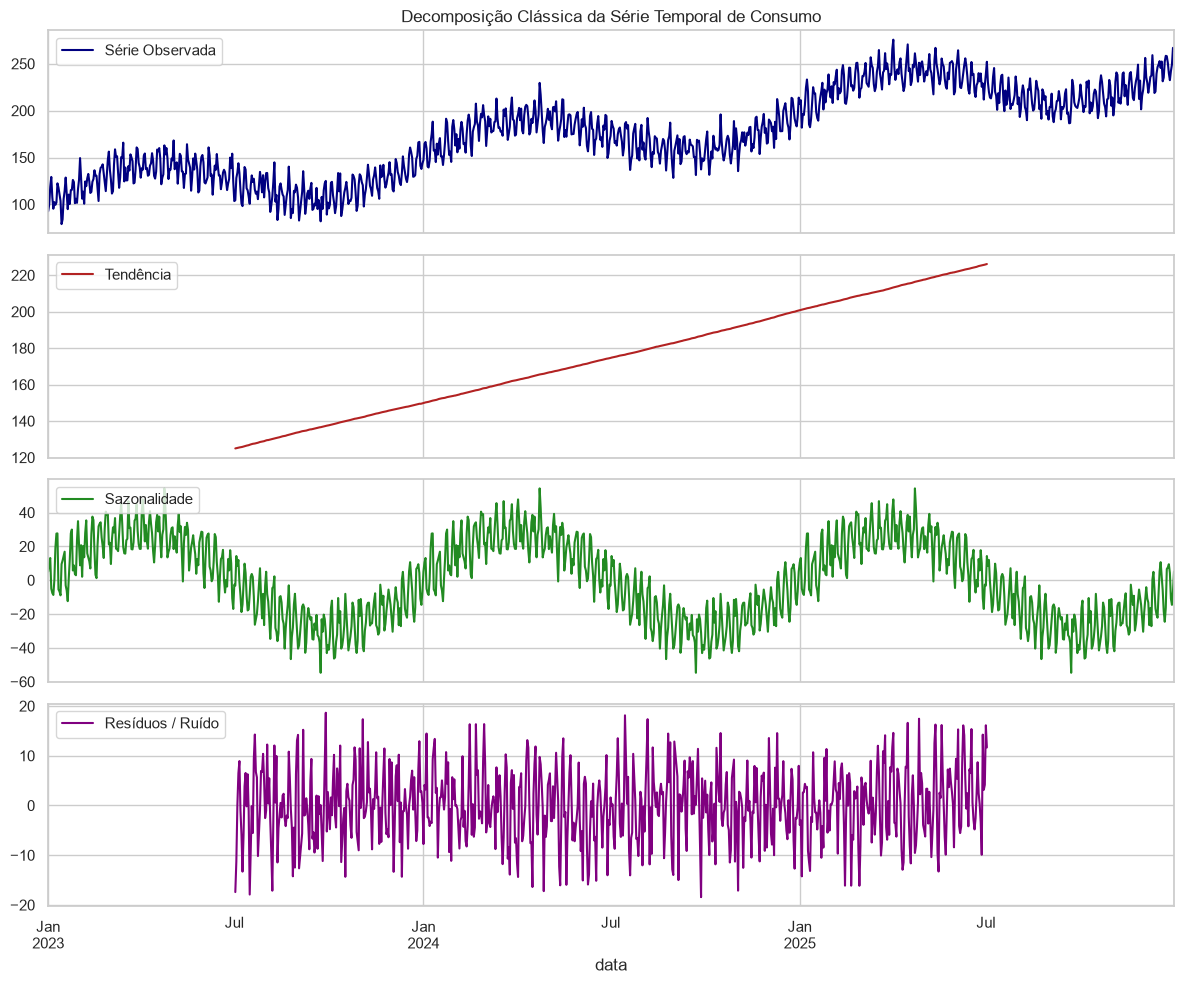

In [7]:
# Cálculo da decomposição
decomposicao = seasonal_decompose(
    df["consumo_mwh"], model="additive", period=365
)

# Construção dos subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposicao.observed.plot(ax=axes[0], color="navy", label="Série Observada")
axes[0].set_title("Decomposição Clássica da Série Temporal de Consumo")
axes[0].legend(loc="upper left")

decomposicao.trend.plot(ax=axes[1], color="firebrick", label="Tendência")
axes[1].legend(loc="upper left")

decomposicao.seasonal.plot(
    ax=axes[2], color="forestgreen", label="Sazonalidade"
)
axes[2].legend(loc="upper left")

decomposicao.resid.plot(ax=axes[3], color="purple", label="Resíduos / Ruído")
axes[3].legend(loc="upper left")

plt.tight_layout()

# Salvando imagem para o README do GitHub
plt.savefig("decomposicao_serie_temporal.png", dpi=300)
plt.show()

## 5. Conclusões Principais da Análise Exploratória

1. **Não-Estacionariedade**: O teste ADF confirmou que a série possui uma tendência determinística crescente significativa, necessitando de transformação/diferenciação ou da inclusão de variáveis de tempo na modelagem.
2. **Componentes Isolados**: A decomposição aditiva extraiu com precisão os ciclos de sazonalidade e isolou os resíduos estocásticos em torno de zero.
3. **Próximo Passo**: Realizar a *Engenharia de Features* (criação de *lags* e janelas móveis) e treinar os modelos de Regressão Avançada (XGBoost e LightGBM).